In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score, f1_score
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Lib loaded")

Lib loaded


In [9]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")
print(df.shape)
print(df.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [10]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
print("Missing values")
print(df.isnull().sum())

Missing values
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole       

In [13]:
#Attrition counts
att_counts=df["Attrition"].value_counts()
print(att_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df=df.drop_duplicates()

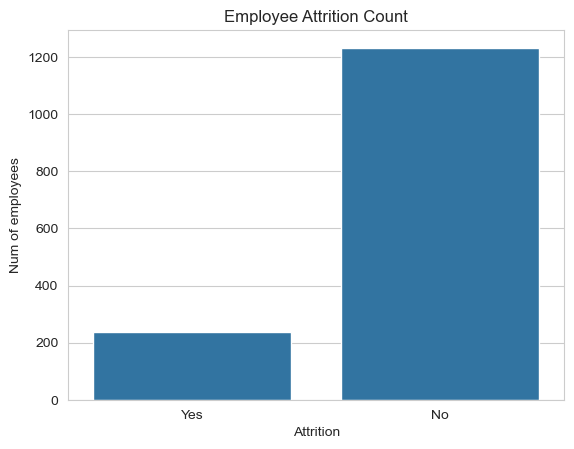

In [16]:
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Num of employees")
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

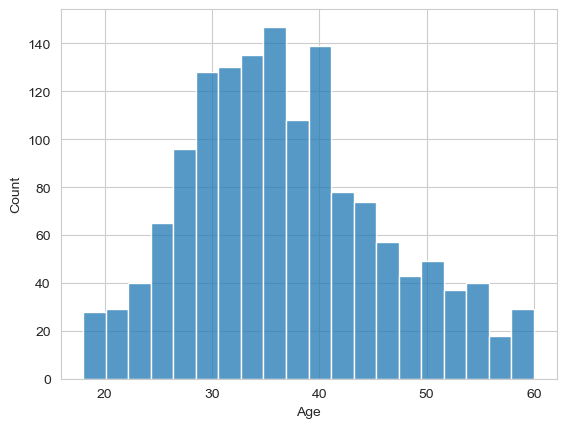

In [17]:
sns.histplot(df["Age"], bins=20)

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

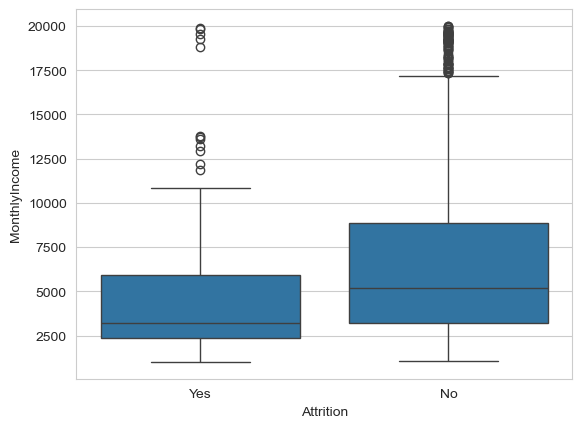

In [18]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

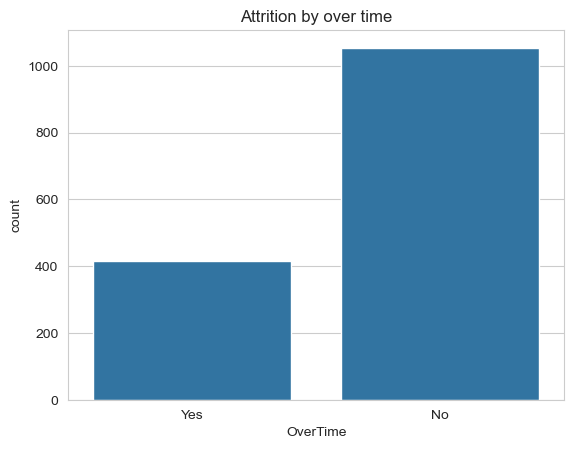

In [19]:
if "OverTime" in df.columns:
    sns.countplot(data=df, x="OverTime")
    plt.title("Attrition by over time")
    plt.show()

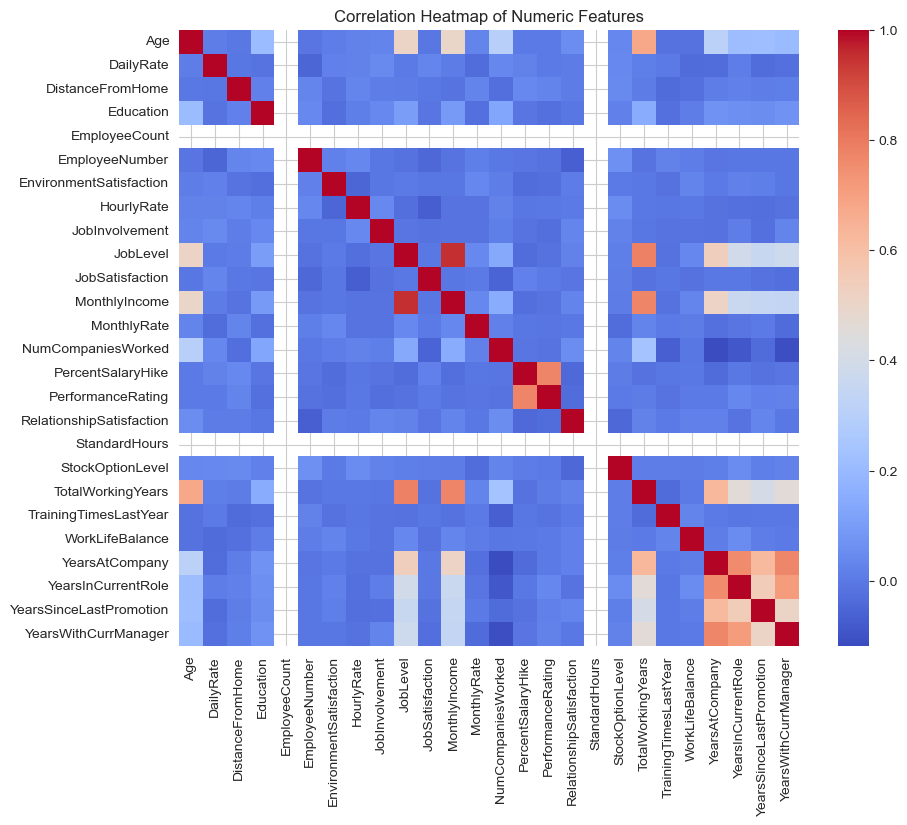

In [20]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_columns].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [21]:
#Pre Processing and Feature Selection
selected_columns = [
    "Age", "Department", "JobRole", "MonthlyIncome", "YearsAtCompany",
    "OverTime", "JobSatisfaction", "TotalWorkingYears", "Attrition"
]

extra_columns = [
    "DistanceFromHome", "EnvironmentSatisfaction","NumCompaniesWorked",
    "WorkLifeBalance", "MaritalStatus", "BusinessTravel", "EducationField", "Gender"
]

for column_name in extra_columns:
    if column_name in df.columns:
        selected_columns.append(column_name)

model_data = df[selected_columns].copy()
model_data = model_data.dropna()
print("Data used for modeling, shape:", model_data.shape)
model_data.head()



Data used for modeling, shape: (1470, 17)


,Age,Department,JobRole,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,TotalWorkingYears,Attrition,DistanceFromHome,EnvironmentSatisfaction,NumCompaniesWorked,WorkLifeBalance,MaritalStatus,BusinessTravel,EducationField,Gender
0,41,Sales,Sales Executive,5993,6,Yes,4,8,Yes,1,2,8,1,Single,Travel_Rarely,Life Sciences,Female
1,49,Research & Development,Research Scientist,5130,10,No,2,10,No,8,3,1,3,Married,Travel_Frequently,Life Sciences,Male
2,37,Research & Development,Laboratory Technician,2090,0,Yes,3,7,Yes,2,4,6,3,Single,Travel_Rarely,Other,Male
3,33,Research & Development,Research Scientist,2909,8,Yes,3,8,No,3,4,1,3,Married,Travel_Frequently,Life Sciences,Female
4,27,Research & Development,Laboratory Technician,3468,2,No,2,6,No,2,1,9,3,Married,Travel_Rarely,Medical,Male


In [22]:
#Encoding
label_encoders={}
categorical_columns=model_data.select_dtypes(include=["object"]).columns.tolist()
categorical_columns.remove("Attrition")

print("Categorical columns to encode:", categorical_columns)

for column_name in categorical_columns:
    encoder=LabelEncoder()
    model_data[column_name]=encoder.fit_transform(model_data[column_name])
    label_encoders[column_name]=encoder

target_encoder=LabelEncoder()
model_data["Attrition"]=target_encoder.fit_transform(model_data["Attrition"])
# After this step: 1 means the employee left, 0 means the employee stayed
print("Attrition classes:", list(target_encoder.classes_))
model_data.head()

Categorical columns to encode: ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel', 'EducationField', 'Gender']
Attrition classes: ['No', 'Yes']


,Age,Department,JobRole,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,TotalWorkingYears,Attrition,DistanceFromHome,EnvironmentSatisfaction,NumCompaniesWorked,WorkLifeBalance,MaritalStatus,BusinessTravel,EducationField,Gender
0,41,2,7,5993,6,1,4,8,1,1,2,8,1,2,2,1,0
1,49,1,6,5130,10,0,2,10,0,8,3,1,3,1,1,1,1
2,37,1,2,2090,0,1,3,7,1,2,4,6,3,2,2,4,1
3,33,1,6,2909,8,1,3,8,0,3,4,1,3,1,1,1,0
4,27,1,2,3468,2,0,2,6,0,2,1,9,3,1,2,3,1


In [23]:
#Train Test Split
X=model_data.drop("Attrition", axis=1)
y=model_data["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
#Feature Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [25]:
log_model=LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred= log_model.predict(X_test_scaled)
y_prob=log_model.predict_proba(X_test_scaled)[:,1]
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_pred, y_prob))

Accuracy : 0.8639455782312925
              precision    recall  f1-score   support

           0       0.88      0.98      0.92       247
           1       0.68      0.28      0.39        47

    accuracy                           0.86       294
   macro avg       0.78      0.63      0.66       294
weighted avg       0.85      0.86      0.84       294

F1 Score : 0.3939393939393939
ROC AUC  : 1.0


In [26]:
decision_tree=DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_scaled, y_train)
dt_prediction=decision_tree.predict(X_test)
dt_probability=decision_tree.predict_proba(X_test)[:,1]

In [27]:
random_forest=RandomForestClassifier(random_state=42, n_estimators=100)
random_forest.fit(X_train, y_train)
rf_prediction=random_forest.predict(X_test)
rf_probability=random_forest.predict_proba(X_test)[:,1]

In [37]:
import joblib

joblib.dump(decision_tree, "../model/dt_model.pkl")
joblib.dump(random_forest, "../model/rf_model.pkl")

print("Decision Tree and Random Forest saved successfully!")

Decision Tree and Random Forest saved successfully!


In [28]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction)
    ],

    "F1 Score":[
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_prediction),
        f1_score(y_test, rf_prediction)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_probability),
        roc_auc_score(y_test, rf_probability)
    ]
})

results

,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.863946,0.393939,0.790335
1,Decision Tree,0.717687,0.450331,0.720002
2,Random Forest,0.826531,0.190476,0.790163


In [29]:
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[241   6]
 [ 34  13]]


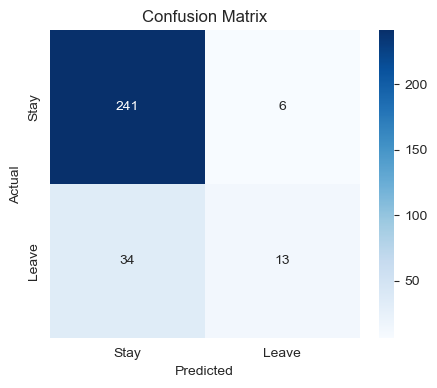

In [30]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Stay", "Leave"],yticklabels=["Stay", "Leave"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
results=results.round(4)
results


,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.8639,0.3939,0.7903
1,Decision Tree,0.7177,0.4503,0.7200
2,Random Forest,0.8265,0.1905,0.7902


In [32]:
best_model_index = results["Accuracy"].idxmax()

best_model_name = results.loc[best_model_index, "Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [33]:
if best_model_name == "Logistic Regression":
    best_model = log_model
    needs_scaling = True

elif best_model_name == "Decision Tree":
    best_model = decision_tree
    needs_scaling = False

else:
    best_model = random_forest
    needs_scaling = False

In [36]:
#Save the Model
joblib.dump(best_model, "../model/best_model.pkl")
joblib.dump(label_encoders, "../model/label_encoders.pkl")
joblib.dump(target_encoder, "../model/target_encoder.pkl")
joblib.dump(scaler, "../model/feature_scaler.pkl")
feature_columns=X.columns.tolist()
model_info = {
    "model_name": best_model_name,
    "feature_columns": selected_columns,
    "categorical_columns": categorical_columns,
    "needs_scaling": needs_scaling,
    "metrics":results.set_index("Model").to_dict("index")
}
joblib.dump(model_info, "../model/model_info.pkl")

print("Best model saved")

Best model saved


In [ ]:
import joblib

model_info = joblib.load("../model/model_info.pkl")
print(model_info)

{'model_name': 'Logistic Regression', 'feature_columns': ['Age', 'Department', 'JobRole', 'MonthlyIncome', 'YearsAtCompany', 'OverTime', 'JobSatisfaction', 'TotalWorkingYears', 'Attrition', 'DistanceFromHome', 'EnvironmentSatisfaction', 'NumCompaniesWorked', 'WorkLifeBalance', 'MaritalStatus', 'BusinessTravel', 'EducationField', 'Gender'], 'categorical_columns': ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel', 'EducationField', 'Gender'], 'needs_scaling': True, 'metrics': {'Logistic Regression': {'Accuracy': 0.8639, 'F1 Score': 0.3939, 'ROC AUC': 0.7903}, 'Decision Tree': {'Accuracy': 0.7177, 'F1 Score': 0.4503, 'ROC AUC': 0.72}, 'Random Forest': {'Accuracy': 0.8265, 'F1 Score': 0.1905, 'ROC AUC': 0.7902}}}
